In [3]:
import os
import pandas as pd
import matplotlib.pylab as plt
from matplotlib import font_manager as fm

from visualisation.custom_colors import *

plt.style.use('default')

font_path = r'C:\Users\Felix\AppData\Local\Microsoft\Windows\Fonts\SourceSansPro-Regular.ttf'
fm.fontManager.addfont(font_path)
source_sans_pro = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = source_sans_pro.get_name()

In [18]:
# STORE = False
STORE = True

In [9]:
hyperparam_importance = {
    "lr": 0.23143,
    "num_layers": 0.16910,
    "concat_tissue_feature": 0.11722,
    "predictor_dropout": 0.08302,
    "predictor_hidden": 0.08216,
    "dropout": 0.07570,
    "grad_clip_norm": 0.06872,
    "seq_only": 0.05641,
    "reset_epochs": 0.04155,
    "seq_encoding": 0.02902,
    "weight_decay": 0.013116,
    "frequency_features": 0.012048,
    "align_aug": 0.0115145,
    "T_mult": 0.009012,
}

df = pd.DataFrame(hyperparam_importance.items(), columns=["hyperparameter", "importance"]).sort_values(by="importance", ascending=False)
df.sort_values(by="importance", ascending=True, inplace=True)

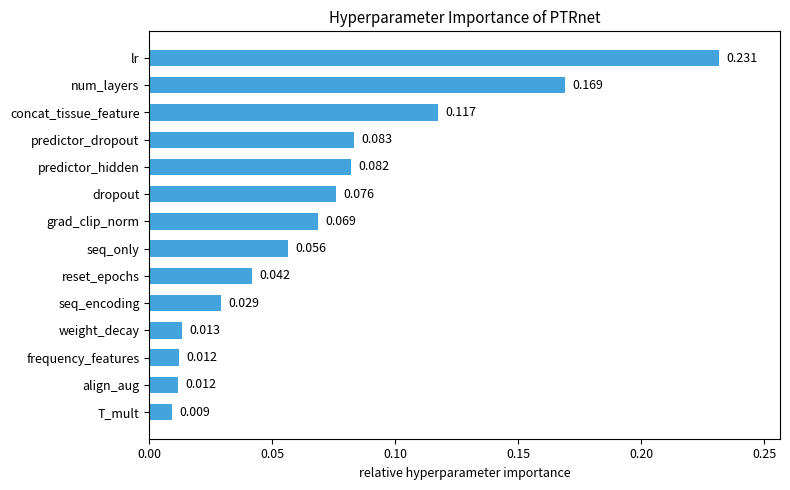

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
bar_height = 0.6
y = range(len(df))

# Simple horizontal barplot for hyperparameter importance
ax.barh(y, df["importance"], height=bar_height, color=blue_shades[2])

# add values to bars
for i, v in enumerate(df["importance"]):
    ax.text(v + 0.003, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

# add spacing to x-axis
ax.set_xlim(0, df["importance"].max() + 0.025)

# Labels and legend
ax.set_yticks(y)
ax.set_yticklabels(df["hyperparameter"])
ax.set_xlabel("relative hyperparameter importance")
ax.set_title("Hyperparameter Importance of PTRnet")
plt.tight_layout()

if STORE:
    plt.savefig(os.getenv("OUTPUT_DIR") + f"/hyperparam_importance_ptrnet.pdf", format="pdf", bbox_inches="tight")

plt.show()